# **Assignment 20: Monthly Milk Production Forecasting (RNN, LSTM, and GRU Deep Learning Models)**

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler

# Set seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

**Step 1: Exploratory Data Analysis (EDA)**

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 168 entries, 1962-01-01 to 1975-12-01
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Production  168 non-null    int64
dtypes: int64(1)
memory usage: 2.6 KB
None

--- Summary Statistics ---
       Production
count  168.000000
mean   754.708333
std    102.204524
min    553.000000
25%    677.750000
50%    761.000000
75%    824.500000
max    969.000000

--- Missing Values Count ---
Production    0
dtype: int64


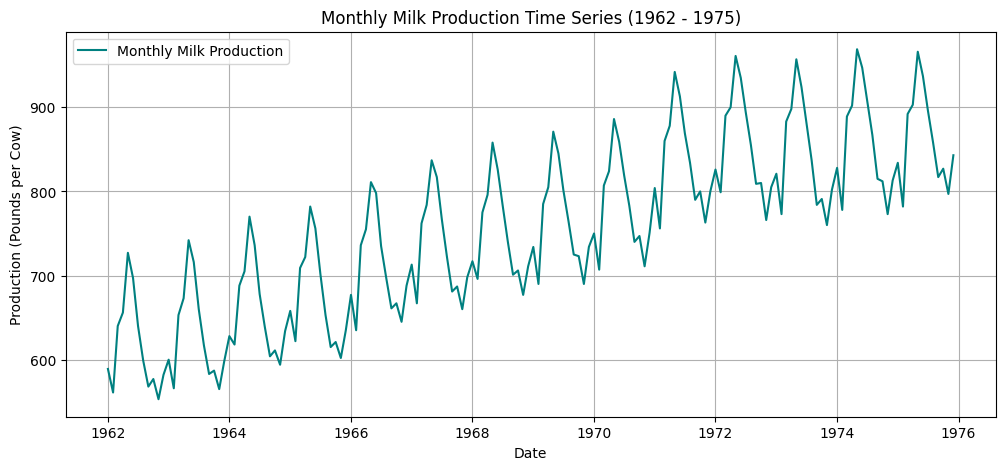

In [4]:
# Load dataset
df_milk = pd.read_csv("/content/monthly_milk_production.csv")
df_milk["Date"] = pd.to_datetime(df_milk["Date"])
df_milk.set_index("Date", inplace=True)

print("--- Dataset Information ---")
print(df_milk.info())

print("\n--- Summary Statistics ---")
print(df_milk.describe())

print("\n--- Missing Values Count ---")
print(df_milk.isnull().sum())

# Plot historical production series to visualize trend and strong yearly seasonality
plt.figure(figsize=(12, 5))
plt.plot(df_milk["Production"], label="Monthly Milk Production", color="teal")
plt.title("Monthly Milk Production Time Series (1962 - 1975)")
plt.xlabel("Date")
plt.ylabel("Production (Pounds per Cow)")
plt.grid(True)
plt.legend()
plt.show()

# Standard Scaling for Deep Learning
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_production = scaler.fit_transform(df_milk[["Production"]].values)

**Step 2: Data Preparation for Deep Learning**

In [5]:
# Create Time Window Sequences (Lookback = 12 Months)
def create_sequences(data, lookback=12):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i : i + lookback])
        y.append(data[i + lookback])
    return np.array(X), np.array(y)


LOOKBACK = 12
X, y = create_sequences(scaled_production, lookback=LOOKBACK)

# Train-Test Split (80% Train, 20% Test)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Convert to PyTorch Tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

print(
    f"Train Input Shape: {X_train_t.shape}, Test Input Shape: {X_test_t.shape}"
)

Train Input Shape: torch.Size([124, 12, 1]), Test Input Shape: torch.Size([32, 12, 1])


**Step 3: Model Building (RNN, LSTM, GRU)**

In [7]:
class SequenceForecaster(nn.Module):

    def __init__(self, mode="RNN", hidden_size=32):
        super().__init__()
        self.mode = mode
        if mode == "RNN":
            self.rnn = nn.RNN(
                input_size=1,
                hidden_size=hidden_size,
                batch_first=True,
                num_layers=1,
            )
        elif mode == "LSTM":
            self.rnn = nn.LSTM(
                input_size=1,
                hidden_size=hidden_size,
                batch_first=True,
                num_layers=1,
            )
        elif mode == "GRU":
            self.rnn = nn.GRU(
                input_size=1,
                hidden_size=hidden_size,
                batch_first=True,
                num_layers=1,
            )

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :])
        return out


def train_and_evaluate(mode, epochs=200, lr=0.01):
    model = SequenceForecaster(mode=mode)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    model.train()
    for epoch in range(epochs):
        optimizer.zero_grad()
        output = model(X_train_t)
        loss = criterion(output, y_train_t)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        preds_scaled = model(X_test_t).numpy()

    # Inverse Transform
    preds = scaler.inverse_transform(preds_scaled)
    actuals = scaler.inverse_transform(y_test)

    # Compute Metrics
    rmse = np.sqrt(mean_squared_error(actuals, preds))
    mae = mean_absolute_error(actuals, preds)
    mape = np.mean(np.abs((actuals - preds) / actuals)) * 100

    return model, preds, actuals, {"RMSE": rmse, "MAE": mae, "MAPE (%)": mape}


# Train All Three Architectures
models_eval = {}
predictions = {}
actual_vals = None

for mode in ["RNN", "LSTM", "GRU"]:
    model, preds, actuals, metrics = train_and_evaluate(mode)
    models_eval[mode] = metrics
    predictions[mode] = preds
    actual_vals = actuals

**Step 4: Model Evaluation & Comparison**


--- Model Performance Metrics Comparison ---
           RMSE        MAE  MAPE (%)
RNN   21.528631  18.281010  2.152689
LSTM  28.442594  24.369562  2.862717
GRU   26.579375  20.482639  2.446178


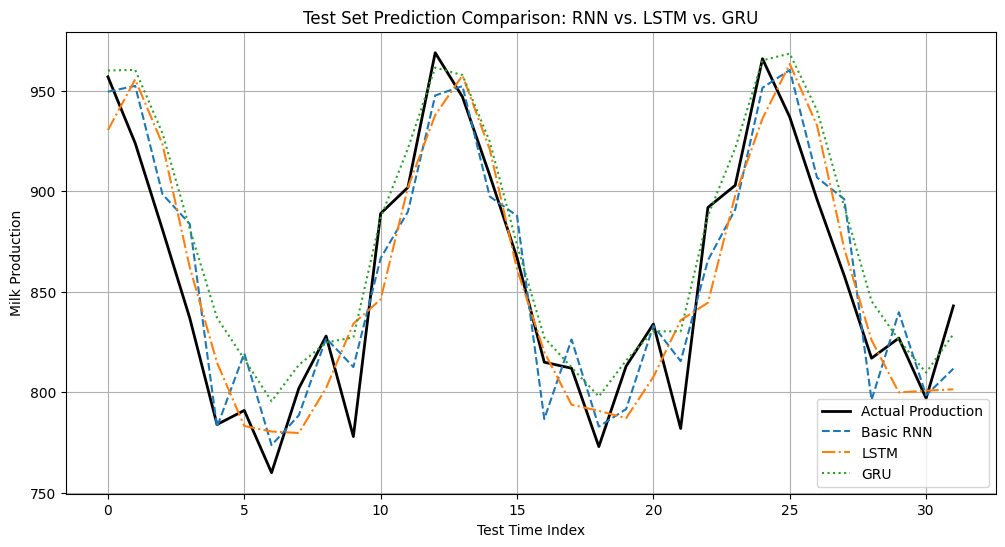

In [8]:
metrics_df = pd.DataFrame(models_eval).T
print("\n--- Model Performance Metrics Comparison ---")
print(metrics_df.to_string())

# Visualize Actual vs Predictions Across Models
plt.figure(figsize=(12, 6))
plt.plot(actual_vals, label="Actual Production", color="black", linewidth=2)
plt.plot(predictions["RNN"], label="Basic RNN", linestyle="--")
plt.plot(predictions["LSTM"], label="LSTM", linestyle="-.")
plt.plot(predictions["GRU"], label="GRU", linestyle=":")
plt.title("Test Set Prediction Comparison: RNN vs. LSTM vs. GRU")
plt.xlabel("Test Time Index")
plt.ylabel("Milk Production")
plt.legend()
plt.grid(True)
plt.show()

**Step 5: 12-Month Out-of-Sample Future Forecasting**


--- 12-Month Ahead Milk Production Forecast ---
            Forecast_Production
1976-01-01           839.591002
1976-02-01           837.011076
1976-03-01           892.064249
1976-04-01           918.914190
1976-05-01           953.802719
1976-06-01           946.277548
1976-07-01           919.922327
1976-08-01           884.305702
1976-09-01           851.980536
1976-10-01           842.292028
1976-11-01           830.219481
1976-12-01           849.969419


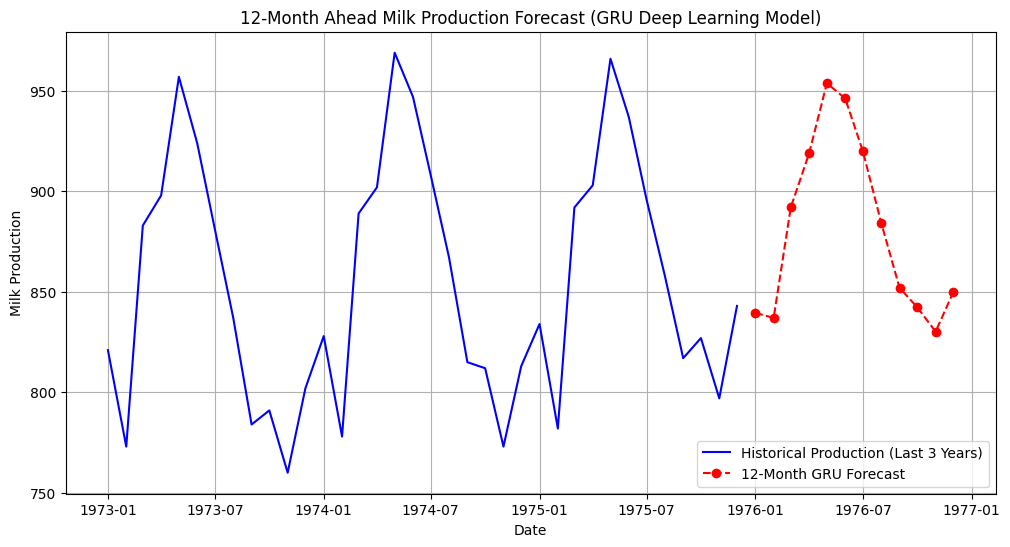

In [9]:
# Use best performing model (GRU) for recursive future forecasting
best_model = SequenceForecaster(mode="GRU")
optimizer = torch.optim.Adam(best_model.parameters(), lr=0.01)
criterion = nn.MSELoss()

for epoch in range(200):
    optimizer.zero_grad()
    loss = criterion(best_model(X_train_t), y_train_t)
    loss.backward()
    optimizer.step()

best_model.eval()

# Recursive 12-Month Forecast
last_window = torch.tensor(
    scaled_production[-LOOKBACK:].reshape(1, LOOKBACK, 1), dtype=torch.float32
)
future_preds_scaled = []

current_window = last_window.clone()
for _ in range(12):
    with torch.no_grad():
        next_pred = best_model(current_window)
        future_preds_scaled.append(next_pred.item())

        # Shift window forward
        next_pred_reshaped = next_pred.reshape(1, 1, 1)
        current_window = torch.cat(
            [current_window[:, 1:, :], next_pred_reshaped], dim=1
        )

future_preds = scaler.inverse_transform(
    np.array(future_preds_scaled).reshape(-1, 1)
)

# Create Future Date Range
future_dates = pd.date_range(
    start=df_milk.index[-1] + pd.DateOffset(months=1), periods=12, freq="MS"
)
forecast_df = pd.DataFrame(future_preds, index=future_dates, columns=["Forecast_Production"])

print("\n--- 12-Month Ahead Milk Production Forecast ---")
print(forecast_df)

# Plot Forecasted Trend
plt.figure(figsize=(12, 6))
plt.plot(
    df_milk.index[-36:],
    df_milk["Production"][-36:],
    label="Historical Production (Last 3 Years)",
    color="blue",
)
plt.plot(
    forecast_df.index,
    forecast_df["Forecast_Production"],
    label="12-Month GRU Forecast",
    color="red",
    marker="o",
    linestyle="--",
)
plt.title("12-Month Ahead Milk Production Forecast (GRU Deep Learning Model)")
plt.xlabel("Date")
plt.ylabel("Milk Production")
plt.legend()
plt.grid(True)
plt.show()